# DistilBERT for sentiment analysis and TextAttack

## Modules setup

In [1]:
!pip -q install textattack==0.3.10 datasets transformers scikit-learn pandas matplotlib nltk

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 36.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 28.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 1.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 4.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 445.7/445.7 kB 38.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 62.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 63.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 23.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

## Imports and configuration

In [2]:
import os
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
from datasets import load_dataset
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix

from transformers import AutoTokenizer, AutoModelForSequenceClassification

import nltk
import textattack
from textattack.models.wrappers import HuggingFaceModelWrapper
from textattack.attack_recipes import TextFoolerJin2019

seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device


textattack: Updating TextAttack package dependencies.
textattack: Downloading NLTK required packages.
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package omw to /root/nltk_data...
[nltk_data] Downloading package universal_tagset to /root/nltk_data...
[nltk_data]   Unzipping taggers/universal_tagset.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
/usr/local/lib/python3.12/dist-packages/jieba/__init__.py:44: SyntaxWarning: invalid escape sequence '\.'
  re_han_default = re.compile("([\u4E00-\u9FD5a-zA-Z0-9+#&\._%\-]+)", re.U)
/usr/local/lib/python3.12/dist-packages/jieba/__init__.py:46: SyntaxWarning: invalid escape s

device(type='cuda')

## Dataset

We use the GLUE SST-2 dataset, which is a binary sentiment benchmark: `0 = negative`, `1 = positive`.

In [3]:
dataset = load_dataset("glue", "sst2")

label_names = ["NEGATIVE", "POSITIVE"]
id2label = {0: "NEGATIVE", 1: "POSITIVE"}
label2id = {v: k for k, v in id2label.items()}

train_df = dataset["train"].to_pandas()[["sentence", "label"]].rename(columns={"sentence": "text"}).reset_index(drop=True)
val_df = dataset["validation"].to_pandas()[["sentence", "label"]].rename(columns={"sentence": "text"}).reset_index(drop=True)

print("train:", train_df.shape)
print("validation:", val_df.shape)
train_df.head()


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

sst2/train-00000-of-00001.parquet:   0%|          | 0.00/3.11M [00:00<?, ?B/s]

sst2/validation-00000-of-00001.parquet:   0%|          | 0.00/72.8k [00:00<?, ?B/s]

sst2/test-00000-of-00001.parquet:   0%|          | 0.00/148k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/67349 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/872 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1821 [00:00<?, ? examples/s]

train: (67349, 2)
validation: (872, 2)


,text,label
0,hide new secretions from the parental units,0
1,"contains no wit , only labored gags",0
2,that loves its characters and communicates som...,1
3,remains utterly satisfied to remain the same t...,0
4,on the worst revenge-of-the-nerds clichés the ...,0


## Victim model

The victim checkpoint is the standard Hugging Face sentiment model `distilbert-base-uncased-finetuned-sst-2-english`.

In [4]:
model_name = "distilbert-base-uncased-finetuned-sst-2-english"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name).to(device)

if tokenizer.pad_token is None:
    tokenizer.add_special_tokens({"pad_token": "[PAD]"})
    model.resize_token_embeddings(len(tokenizer))

model.config.id2label = id2label
model.config.label2id = label2id
model.eval()

print("tokenizer.pad_token:", tokenizer.pad_token)
print("tokenizer.pad_token_id:", tokenizer.pad_token_id)
print("model.config.id2label:", model.config.id2label)
print("model.config.label2id:", model.config.label2id)
print(model.config)


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

tokenizer.pad_token: [PAD]
tokenizer.pad_token_id: 0
model.config.id2label: {0: 'NEGATIVE', 1: 'POSITIVE'}
model.config.label2id: {'NEGATIVE': 0, 'POSITIVE': 1}
DistilBertConfig {
  "activation": "gelu",
  "architectures": [
    "DistilBertForSequenceClassification"
  ],
  "attention_dropout": 0.1,
  "dim": 768,
  "dropout": 0.1,
  "dtype": "float32",
  "finetuning_task": "sst-2",
  "hidden_dim": 3072,
  "id2label": {
    "0": "NEGATIVE",
    "1": "POSITIVE"
  },
  "initializer_range": 0.02,
  "label2id": {
    "NEGATIVE": 0,
    "POSITIVE": 1
  },
  "max_position_embeddings": 512,
  "model_type": "distilbert",
  "n_heads": 12,
  "n_layers": 6,
  "output_past": true,
  "pad_token_id": 0,
  "qa_dropout": 0.1,
  "seq_classif_dropout": 0.2,
  "sinusoidal_pos_embds": false,
  "tie_weights_": true,
  "transformers_version": "4.57.6",
  "vocab_size": 30522
}



## Baseline run

A unified prediction function.

In [5]:
def predict_texts(texts, batch_size=32, max_length=256):
    if isinstance(texts, str):
        texts = [texts]
    texts = list(texts)

    preds = []
    probs = []

    for i in range(0, len(texts), batch_size):
        batch_texts = texts[i:i + batch_size]
        enc = tokenizer(
            batch_texts,
            padding=True,
            truncation=True,
            max_length=max_length,
            return_tensors="pt",
        )
        enc = {k: v.to(device) for k, v in enc.items()}

        with torch.inference_mode():
            logits = model(**enc).logits
            batch_probs = torch.softmax(logits, dim=-1)

        batch_pred_ids = batch_probs.argmax(dim=-1).tolist()
        preds.extend(batch_pred_ids)
        probs.extend(batch_probs.detach().cpu().tolist())

    pred_labels = [model.config.id2label[int(i)] for i in preds]
    return preds, pred_labels, probs


## Clean evaluation

In [7]:
def evaluate_frame(df, text_col="text", label_col="label", batch_size=32, max_length=256):
    texts = df[text_col].tolist()
    y_true = df[label_col].astype(int).tolist()

    pred_ids, pred_labels, prob_rows = predict_texts(texts, batch_size=batch_size, max_length=max_length)

    y_pred = np.array(pred_ids, dtype=int)
    y_true = np.array(y_true, dtype=int)

    accuracy = accuracy_score(y_true, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="binary", zero_division=0)

    out = df.copy()
    out["pred_id"] = pred_ids
    out["pred_label"] = pred_labels
    out["pred_prob_neg"] = [row[0] for row in prob_rows]
    out["pred_prob_pos"] = [row[1] for row in prob_rows]
    out["correct"] = (out[label_col].astype(int) == out["pred_id"].astype(int))

    metrics = {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
    }
    return out, metrics

Results for the clean model are solid.

In [8]:
clean_val_df, clean_val_metrics = evaluate_frame(val_df)
clean_val_metrics

{'accuracy': 0.9105504587155964,
 'precision': 0.8978260869565218,
 'recall': 0.9301801801801802,
 'f1': 0.9137168141592921}

Confusion matrix.

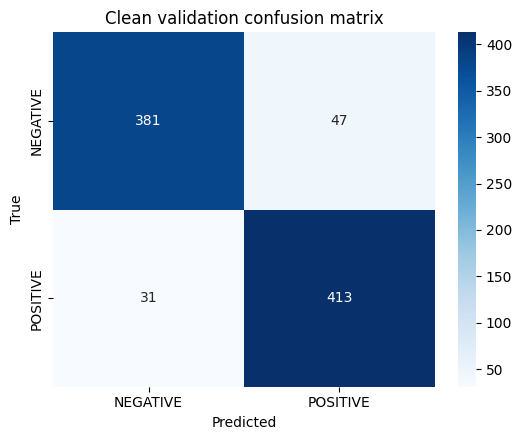

In [10]:
cm_clean = confusion_matrix(clean_val_df["label"], clean_val_df["pred_id"], labels=[0, 1])

fig, ax = plt.subplots(figsize=(5.5, 4.5))
sns.heatmap(
    cm_clean,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_names,
    yticklabels=label_names,
    ax=ax,
)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Clean validation confusion matrix")
plt.tight_layout()
plt.show()

## TextAttack setup

TextAttack wraps Hugging Face models through `HuggingFaceModelWrapper`, and attack recipes are built with `TextFoolerJin2019.build(model_wrapper)`.

`TextFoolerJin2019` is a black-box adversarial attack framework designed to fool NLP models by identifying and replacing the most influential words in a text. It utilizes a combination of word importance ranking and synonym substitution based on semantic similarity to generate adversarial examples.

This method ensures that the resulting text remains grammatically correct and semantically consistent to human readers while successfully misleading the classifier.

In [12]:
model_wrapper = HuggingFaceModelWrapper(model, tokenizer)
attack = TextFoolerJin2019.build(model_wrapper)

if device.type == "cuda":
    attack.cuda_()

textattack: Downloading https://textattack.s3.amazonaws.com/word_embeddings/paragramcf.
100%|██████████| 481M/481M [00:13<00:00, 36.8MB/s]
textattack: Unzipping file /root/.cache/textattack/tmp3rn7ov7t.zip to /root/.cache/textattack/word_embeddings/paragramcf.
textattack: Successfully saved word_embeddings/paragramcf to cache.
textattack: Unknown if model of class <class 'transformers.models.distilbert.modeling_distilbert.DistilBertForSequenceClassification'> compatible with goal function <class 'textattack.goal_functions.classification.untargeted_classification.UntargetedClassification'>.


'Attack'

## Attack subset

We attack only a small balanced subset of examples that the model already classifies correctly. This keeps the notebook practical and makes the output easier to inspect.

In [13]:
correct_df = clean_val_df[clean_val_df["correct"]].copy()

n_per_class = 5
parts = []
for label_id in [0, 1]:
    class_df = correct_df[correct_df["label"] == label_id]
    sample_n = min(n_per_class, len(class_df))
    parts.append(class_df.sample(n=sample_n, random_state=seed))

In [14]:
print(parts)

[                                                  text  label  pred_id  \
606  makes for a pretty unpleasant viewing experien...      0        0   
461  it 's too bad that the helping hand he uses to...      0        0   
108  too often , the viewer is n't reacting to humo...      0        0   
133  the tale of tok ( andy lau ) , a sleek sociopa...      0        0   
136  looks and feels like a project better suited f...      0        0   

    pred_label  pred_prob_neg  pred_prob_pos  correct  
606   NEGATIVE       0.999336       0.000664     True  
461   NEGATIVE       0.999805       0.000195     True  
108   NEGATIVE       0.994833       0.005167     True  
133   NEGATIVE       0.999547       0.000453     True  
136   NEGATIVE       0.998721       0.001278     True  ,                                                   text  label  pred_id  \
834  collateral damage finally delivers the goods f...      1        1   
744                              one from the heart .       1        

In [15]:
attack_df = (
    pd.concat(parts, axis=0)
    .sample(frac=1.0, random_state=seed)
    .reset_index(drop=True)
)

print("Attack subset size:", len(attack_df))
attack_df[["text", "label", "pred_label"]].head()

Attack subset size: 10


,text,label,pred_label
0,the film will play equally well on both the st...,1,POSITIVE
1,it 's too bad that the helping hand he uses to...,0,NEGATIVE
2,collateral damage finally delivers the goods f...,1,POSITIVE
3,makes for a pretty unpleasant viewing experien...,0,NEGATIVE
4,trademark american triteness and simplicity ar...,1,POSITIVE


Attack function for a single example.

In [16]:
def attack_one(text, label):
    result = attack.attack(text, int(label))
    result_type = type(result).__name__

    if "Successful" in result_type:
        status = "success"
        adv_text = result.perturbed_text()
    elif "Failed" in result_type:
        status = "fail"
        adv_text = text
    else:
        status = "skip"
        adv_text = text

    adv_pred_ids, adv_pred_labels, adv_prob_rows = predict_texts([adv_text])

    return {
        "text": text,
        "label": int(label),
        "clean_pred": None,
        "clean_pred_label": None,
        "adv_text": adv_text,
        "adv_pred": int(adv_pred_ids[0]),
        "adv_pred_label": adv_pred_labels[0],
        "status": status,
        "num_queries": getattr(result, "num_queries", None),
        "result_type": result_type,
        "adv_prob_neg": float(adv_prob_rows[0][0]),
        "adv_prob_pos": float(adv_prob_rows[0][1]),
    }

Attack with adversarial examples. 9/10 labels are successfully swaped.

In [19]:
from tqdm.auto import tqdm

attack_rows = []
for i in tqdm(range(len(attack_df))):
    row = attack_df.iloc[i]
    clean_pred = int(row["pred_id"])
    clean_pred_label = model.config.id2label[clean_pred]

    record = attack_one(row["text"], row["label"])
    record["clean_pred"] = clean_pred
    record["clean_pred_label"] = clean_pred_label
    attack_rows.append(record)

attack_results_df = pd.DataFrame(attack_rows)
attack_results_df

  0%|          | 0/10 [00:00<?, ?it/s]

,text,label,clean_pred,clean_pred_label,adv_text,adv_pred,adv_pred_label,status,num_queries,result_type,adv_prob_neg,adv_prob_pos
0,the film will play equally well on both the st...,1,1,POSITIVE,the film alacrity play equally verywell on bot...,0,NEGATIVE,success,56,SuccessfulAttackResult,0.991655,0.008345
1,it 's too bad that the helping hand he uses to...,0,0,NEGATIVE,it 's too wicked that the relief hand he uses ...,1,POSITIVE,success,126,SuccessfulAttackResult,0.012400,0.987600
2,collateral damage finally delivers the goods f...,1,1,POSITIVE,collateral damage finally supplying the goods ...,0,NEGATIVE,success,57,SuccessfulAttackResult,0.997649,0.002351
3,makes for a pretty unpleasant viewing experien...,0,0,NEGATIVE,makes for a pretty outrageous viewing experien...,1,POSITIVE,success,44,SuccessfulAttackResult,0.001338,0.998662
4,trademark american triteness and simplicity ar...,1,1,POSITIVE,trademark american triteness and facile are to...,0,NEGATIVE,success,68,SuccessfulAttackResult,0.917600,0.082400
5,"too often , the viewer is n't reacting to humo...",0,0,NEGATIVE,"too seldom , the onlookers is n't reacting to ...",1,POSITIVE,success,153,SuccessfulAttackResult,0.051255,0.948745
6,"without ever becoming didactic , director carl...",1,1,POSITIVE,"without ever becoming didactic , director carl...",0,NEGATIVE,success,60,SuccessfulAttackResult,0.966500,0.033500
7,looks and feels like a project better suited f...,0,0,NEGATIVE,looks and feels like a project nicest suited f...,1,POSITIVE,success,14,SuccessfulAttackResult,0.002989,0.997011
8,"the tale of tok ( andy lau ) , a sleek sociopa...",0,0,NEGATIVE,"the tale of tok ( andy lau ) , a sleek sociopa...",0,NEGATIVE,fail,314,FailedAttackResult,0.999547,0.000453
9,one from the heart .,1,1,POSITIVE,one from the crux .,0,NEGATIVE,success,31,SuccessfulAttackResult,0.982558,0.017441


## Metrics

In [21]:
def metrics_row(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="binary", zero_division=0)
    return {"accuracy": acc, "precision": precision, "recall": recall, "f1": f1}

y_true_attack = attack_results_df["label"].to_numpy()
clean_pred_attack = attack_results_df["clean_pred"].to_numpy()
adv_pred_attack = attack_results_df["adv_pred"].to_numpy()

clean_metrics = metrics_row(y_true_attack, clean_pred_attack)
adv_metrics = metrics_row(y_true_attack, adv_pred_attack)

attack_success_rate = float((attack_results_df["status"] == "success").mean())
attack_metrics = pd.DataFrame([
    {"stage": "clean", **clean_metrics},
    {"stage": "adversarial", **adv_metrics},
])

attack_metrics


,stage,accuracy,precision,recall,f1
0,clean,1.0,1.0,1.0,1.0
1,adversarial,0.1,0.0,0.0,0.0


## Confusion matrix

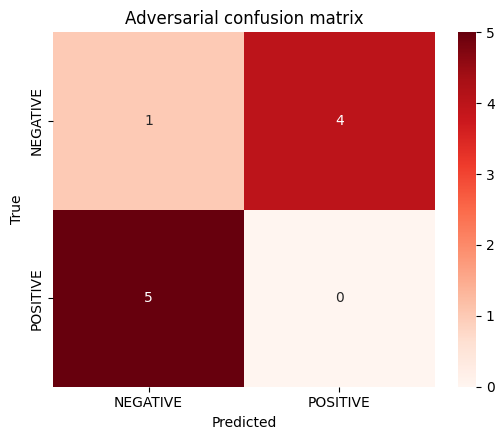

In [22]:
cm_adv = confusion_matrix(y_true_attack, adv_pred_attack, labels=[0, 1])

fig, ax = plt.subplots(figsize=(5.5, 4.5))
sns.heatmap(
    cm_adv,
    annot=True,
    fmt="d",
    cmap="Reds",
    xticklabels=label_names,
    yticklabels=label_names,
    ax=ax,
)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Adversarial confusion matrix")
plt.tight_layout()
plt.show()


Example adversarial texts.

In [23]:
preview = attack_results_df[["label", "clean_pred", "adv_pred", "status", "text", "adv_text"]].head(8).copy()
preview["label"] = preview["label"].map(model.config.id2label)
preview["clean_pred"] = preview["clean_pred"].map(model.config.id2label)
preview["adv_pred"] = preview["adv_pred"].map(model.config.id2label)
preview


,label,clean_pred,adv_pred,status,text,adv_text
0,POSITIVE,POSITIVE,NEGATIVE,success,the film will play equally well on both the st...,the film alacrity play equally verywell on bot...
1,NEGATIVE,NEGATIVE,POSITIVE,success,it 's too bad that the helping hand he uses to...,it 's too wicked that the relief hand he uses ...
2,POSITIVE,POSITIVE,NEGATIVE,success,collateral damage finally delivers the goods f...,collateral damage finally supplying the goods ...
3,NEGATIVE,NEGATIVE,POSITIVE,success,makes for a pretty unpleasant viewing experien...,makes for a pretty outrageous viewing experien...
4,POSITIVE,POSITIVE,NEGATIVE,success,trademark american triteness and simplicity ar...,trademark american triteness and facile are to...
5,NEGATIVE,NEGATIVE,POSITIVE,success,"too often , the viewer is n't reacting to humo...","too seldom , the onlookers is n't reacting to ..."
6,POSITIVE,POSITIVE,NEGATIVE,success,"without ever becoming didactic , director carl...","without ever becoming didactic , director carl..."
7,NEGATIVE,NEGATIVE,POSITIVE,success,looks and feels like a project better suited f...,looks and feels like a project nicest suited f...


Results to csv.

In [24]:
attack_results_df.to_csv("sst2_textattack_results.csv", index=False)
attack_metrics.to_csv("sst2_textattack_summary.csv", index=False)